# Fig 5c — E6 sustained throughput (filtered + aligned)

Companion to Fig 5/5b. Same 9×3 grid, but the heat value is the *sustained
throughput* (kbps) the link held — the slow-EMA bandwidth estimate the ABR
steers on, time-averaged per cell. Unlike the delivered-goodput panel it is
not scaled by the selected tier, and it damps the push-rate burst that
inflates raw per-object throughput
(see _data.compute_avg_sustained_throughput_kbps).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "figures"))

import matplotlib.pyplot as plt
import numpy as np

from _data import (
    E6_COL_ORDER,
    E6_ROW_ORDER,
    e6_sustained_throughput_matrix,
)
from _style import TEXT_WIDTH_IN, apply_acm_style

apply_acm_style()

In [2]:
matrix = e6_sustained_throughput_matrix()

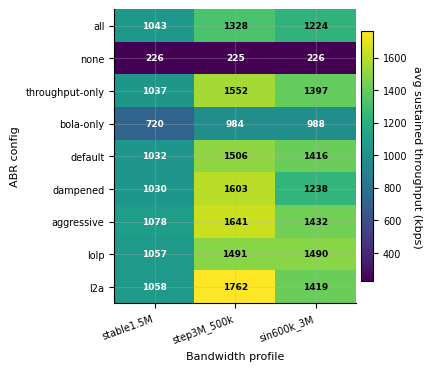

In [3]:
fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN * 0.6, 3.6), constrained_layout=True)

masked = np.ma.masked_invalid(matrix.values)
im = ax.imshow(masked, cmap="viridis", aspect="auto",
               interpolation="nearest", origin="upper")
ax.set_xticks(range(len(E6_COL_ORDER)))
ax.set_xticklabels(E6_COL_ORDER, rotation=20, ha="right")
ax.set_yticks(range(len(E6_ROW_ORDER)))
ax.set_yticklabels(E6_ROW_ORDER, fontsize=7)
ax.set_xlabel("Bandwidth profile")
ax.set_ylabel("ABR config")

for i, row in enumerate(E6_ROW_ORDER):
    for j, col in enumerate(E6_COL_ORDER):
        value = matrix.iloc[i, j]
        if np.isnan(value):
            ax.text(j, i, "—", ha="center", va="center", color="#999999", fontsize=7)
            continue
        rgba = im.cmap(im.norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "white" if luminance < 0.5 else "black"
        ax.text(j, i, f"{value:.0f}", ha="center", va="center",
                color=text_color, fontsize=6.5, weight="bold")

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("avg sustained throughput (kbps)", rotation=270, labelpad=10)

In [4]:
fig.savefig(Path.cwd().parent / "figures" / "fig5c_e6_throughput.pdf")
fig.savefig(Path.cwd().parent / "figures" / "fig5c_e6_throughput.png", dpi=200)